# Test out the functionality

This command line worked:  
py refs/stippler.py test.png --save --force --n_point 5000 --n_iter 50 --pointsize 1.0 1.0 --figsize 6 --interactive --channel red

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import imageio as iio
import scipy
import tqdm

In [3]:
def normalize(D):
    """
    Normalize the values.

    If the contrast is high, return normalized. Otherwise ceil values to 1s.
    """
    Vmin, Vmax = D.min(), D.max()
    if Vmax - Vmin > 1e-5:
        return (D-Vmin)/(Vmax-Vmin)
    return np.ones_like(D)


def initialization(n, density):
    """
    Return n points distributed over [xmin, xmax] x [ymin, ymax]
    according to (normalized) density distribution.

    with xmin, xmax = 0, density.shape[1]
         ymin, ymax = 0, density.shape[0]

    The algorithm here is a simple rejection sampling.
    """

    samples = []
    while len(samples) < n:
        # X = np.random.randint(0, density.shape[1], 10*n)
        # Y = np.random.randint(0, density.shape[0], 10*n)
        X = np.random.uniform(0, density.shape[1], 10*n)
        Y = np.random.uniform(0, density.shape[0], 10*n)
        P = np.random.uniform(0, 1, 10*n)
        index = 0
        while index < len(X) and len(samples) < n:
            x, y = X[index], Y[index]
            x_, y_ = int(np.floor(x)), int(np.floor(y))
            if P[index] < density[y_, x_]:
                samples.append([x, y])
            index += 1
    return np.array(samples)

### Try to recreate the functionality in the notebook

In [4]:
filename = "test.png"

In [5]:
channels = {
     "red"   : 0,
     "green" : 1,
     "blue"  : 2,
     "alpha" : 3 
}

default = {
    "seed" : 1,
    "n_point": 5000,
    "n_iter": 50,
    "channel" : "alpha",
    "inverse" : False,
    "normalize" : False,
    "force": False,
    "save": False,
    "figsize": 6,
    "display": False,
    "interactive": False,
    "pointsize": (1.0, 1.0),
}

In [6]:
# Random seed initialization
np.random.seed(default["seed"])

In [7]:
# load the reference image and normalize it (x/255)
image = iio.imread(filename) / 255.0

C:\Users\Fiona\AppData\Local\Temp\ipykernel_13732\3008278305.py:2: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = iio.imread(filename) / 255.0


In [8]:
image

array([[[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        ...,
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]],

       [[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        ...,
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]],

       [[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        ...,
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]],

       ...,

       [[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        ...,
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]],

       [[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        ...,
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]],

       [[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        ...,
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]]], shape=(268, 358, 3))

In [9]:
# get the channel's normalized (0-1) value and 1-x it.
density = 1.0 - image[:,:, channels["red"]]

In [10]:
density

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(268, 358))

In [11]:
# Recalculate density values in sufficient resolution
# I wonder if the desired resolution of 2000x2000 correlates to the default n of points: 5000.
# Might it work out to keep resolution and n of points in the same order of magnitude?
## We want (approximately) an image > 2000X2000
zoom = int(np.ceil(2*1024 / max(density.shape[0],density.shape[1])))
density = scipy.ndimage.zoom(density, zoom, order=0)
density = normalize(density)
density_P = density.cumsum(axis=1) # cumulative sum of the rows
density_Q = density_P.cumsum(axis=1) # cumulative sum of the sum of the rows

In [36]:
# initialize
points = initialization(default["n_point"], density)

Here is the n_iter which I do not understand yet.

In [13]:
import refs.voronoi as voronoi

In [14]:
# massage the points into proper place?
# Maybe this gets rid of the random seeding of the initial points
for i in tqdm.trange(default["n_iter"]):
    regions, points = voronoi.centroids(points, density, density_P, density_Q)

100%|██████████| 50/50 [01:10<00:00,  1.42s/it]


The points are the centroids of the voronoi around the stippled points.

In [35]:
centroid_points = points

In [16]:
points

array([[ 364.21145868, 1204.32487001],
       [ 349.81573636, 1186.67112898],
       [ 376.76555051, 1221.86002847],
       ...,
       [ 740.07953626, 1068.79639931],
       [ 725.2407154 , 1041.74277993],
       [ 723.8933245 , 1062.59644856]], shape=(5000, 2))

In [18]:
regions

[[883, 881, 880, 879, 882],
 [882, 877, 350, 348, 148, 355, 879],
 [885, 358, 883, 881, 884],
 [891, 887, 888, 889, 890],
 [893, 359, 347, 348, 148, 892],
 [1124, 1121, 106, 560, 1123],
 [1126, 353, 352, 354, 1125],
 [1133, 1129, 1130, 1131, 1128, 1132],
 [1147, 560, 1123, 1133, 1132, 1145],
 [1146, 1134, 1135, 1128, 1132, 1145],
 [1148, 1141, 1142, 562, 106, 560, 1147],
 [1151, 1141, 1142, 1144, 1143, 1150],
 [1153, 1148, 1141, 1151, 1149, 1152],
 [1155, 1146, 1145, 1147, 1148, 1153],
 [1155, 1146, 1134, 1136, 561, 1154],
 [1634, 1632, 1630, 1627, 1629, 1633],
 [1647, 1643, 735, 736, 733, 734, 1646],
 [1682, 1644, 1643, 1647, 1648, 1681],
 [1708, 1705, 1704, 755, 1707],
 [1722, 757, 758, 756, 760, 761, 1721],
 [2152, 2149, 2148, 2150, 2151],
 [2150, 890, 891, 359, 347, 2148],
 [2155, 1751, 1753, 1748, 2154],
 [2159, 357, 358, 885, 886, 2158],
 [2163, 889, 890, 2150, 2151, 2162],
 [2166, 356, 880, 879, 355, 2164],
 [2165, 892, 148, 355, 2164],
 [2182, 2178, 2179, 2180, 2181],
 [2542, 1

In [37]:
xes = [p[0] for p in points.tolist()]
yes = [p[1] for p in points.tolist()]

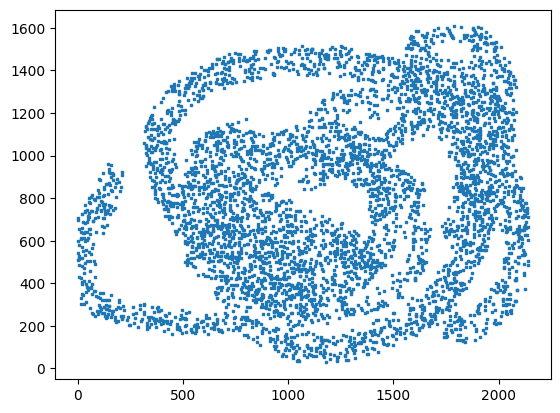

In [ ]:
# try and visualize it before massaging
p = plt.scatter(xes, yes, marker=",", s=1)

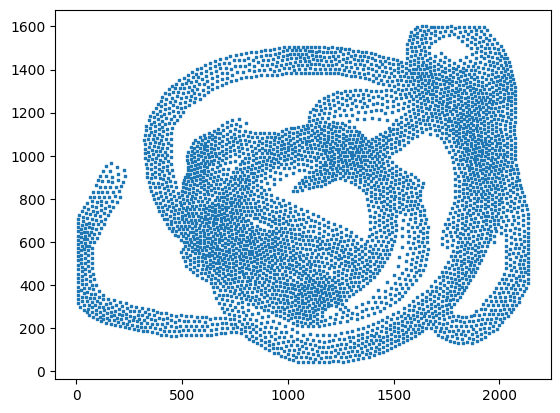

In [ ]:
# visualize it after massaging
x_voro = [p[0] for p in centroid_points.tolist()]
y_voro = [p[1] for p in centroid_points.tolist()]

p = plt.scatter(x_voro, y_voro, marker=",", s=1)

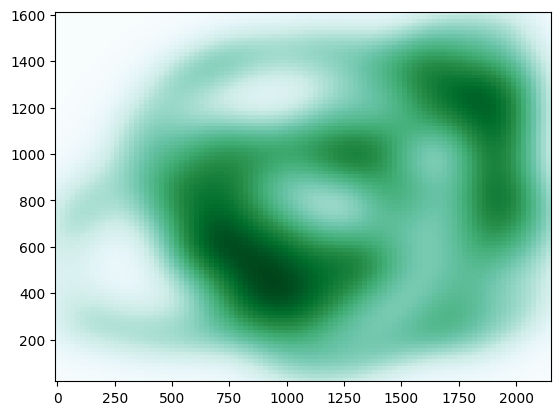

In [ ]:
# try make a gradient from this again
from scipy.stats import gaussian_kde

x, y = points.T
nbins = 100

# Evaluate a gaussian kde on a regular grid of nbins x nbins over data extents
k = gaussian_kde(points.T)
xi, yi = np.mgrid[x.min():x.max():nbins*1j, y.min():y.max():nbins*1j]
zi = k(np.vstack([xi.flatten(), yi.flatten()]))
 
# plot a density

plt.pcolormesh(xi, yi, zi.reshape(xi.shape), shading='auto', cmap=plt.cm.BuGn)